In [1]:
# =============================================================================
# Projeto de Inteligencia Artificial - 7K SI Noite - Prof. Dr. Leandro Zerbinatti
# Universidade Presbiteriana Mackenzie - Faculdade de Computacao e Informatica
#
# Titulo do arquivo: eda_prep.ipynb
# Sintese do conteudo: Analise exploratoria de dados (EDA) e preparacao dos
#   dados financeiros de 4 varejistas brasileiras de capital aberto
#   (Magazine Luiza, Americanas, Via/Grupo Casas Bahia, Lojas Renner),
#   2020-2024, para o projeto "Analise de risco financeiro e deteccao de
#   sinais de alerta em relatorios de RI via LLM" (Opcao API de LLM - N1).
#
# Integrantes do grupo:
#   - Cristiano Morales      | RA 10437953 | 10437953@mackenzista.com.br
#   - Caio Carames           | RA 10308718 | 10308718@mackenzista.com.br
#   - Leonardo Tonon         | RA 10426930 | 10426930@mackenzista.com.br
#
# Historico de atualizacoes:
#   2026-09-13 | Cristiano Morales | Criacao do notebook: carga do dataset,
#               limpeza/preparacao dos dados, analise exploratoria (estatisticas
#               descritivas, tratamento de valores ausentes, visualizacoes de
#               tendencia e comparacao entre empresas) para a entrega N1.
# =============================================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

In [3]:
# Dataset original, capturado manualmente pelo grupo a partir de divulgacoes
# oficiais de RI e de imprensa especializada (ver dataset/fontes.csv).
df = pd.read_csv("../dataset/demonstrativos_financeiros_varejo_br.csv")

print("Dimensoes do dataset:", df.shape)
df.head(20)

Dimensoes do dataset: (18, 9)


,empresa,ticker,ano,receita_liquida_r_milhoes,resultado_liquido_r_milhoes,patrimonio_liquido_r_milhoes,divida_bruta_r_milhoes,divida_liquida_r_milhoes,observacao
0,Magazine Luiza,MGLU3,2020,"29,235.0",391.7,"7,300.0",NaN,"-1,200.0",Ano pre-pandemia/pandemia; posicao de caixa li...
1,Magazine Luiza,MGLU3,2021,"35,300.0",590.7,"11,300.0",NaN,"2,700.0",NaN
2,Magazine Luiza,MGLU3,2022,"37,299.0",-499.0,"10,648.7","7,108.8",NaN,Prejuizo no exercicio
3,Magazine Luiza,MGLU3,2023,"36,768.1",-979.1,"9,610.5","5,354.9",NaN,Prejuizo aprofundado; reducao de divida bruta
4,Magazine Luiza,MGLU3,2024,NaN,NaN,NaN,NaN,NaN,Nao coletado nesta rodada (ver secao de limita...
5,Americanas,AMER3,2020,NaN,NaN,NaN,NaN,NaN,Nao coletado (pre-fraude; fora do periodo crit...
6,Americanas,AMER3,2021,"22,521.0","-6,237.0",NaN,NaN,"13,945.0",Valores republicados (restatement) apos descob...
7,Americanas,AMER3,2022,"25,800.0","-12,912.0","-26,700.0","37,300.0","26,300.0",Ano de descoberta publica da fraude contabil (...
8,Americanas,AMER3,2023,"14,900.0","-2,270.0","-28,800.0","39,400.0",NaN,Empresa em recuperacao judicial
9,Americanas,AMER3,2024,"14,300.0","8,200.0",NaN,NaN,NaN,Resultado positivo puxado por ganho financeiro...


In [4]:
print(df.info())
print("\nValores ausentes por coluna:")
print(df.isna().sum())

# Percentual de completude por coluna (relevante para discutir qualidade dos dados)
completude = (1 - df.isna().mean()) * 100
print("\n% de completude por coluna:")
print(completude.round(1))

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   empresa                       18 non-null     str    
 1   ticker                        18 non-null     str    
 2   ano                           18 non-null     int64  
 3   receita_liquida_r_milhoes     14 non-null     float64
 4   resultado_liquido_r_milhoes   14 non-null     float64
 5   patrimonio_liquido_r_milhoes  8 non-null      float64
 6   divida_bruta_r_milhoes        6 non-null      float64
 7   divida_liquida_r_milhoes      5 non-null      float64
 8   observacao                    17 non-null     str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.4 KB
None

Valores ausentes por coluna:
empresa                          0
ticker                           0
ano                              0
receita_liquida_r_milhoes        4
resultado_liquido_r_milhoes

In [5]:
# 4.1 Padronizacao de tipos
num_cols = [
    "receita_liquida_r_milhoes",
    "resultado_liquido_r_milhoes",
    "patrimonio_liquido_r_milhoes",
    "divida_bruta_r_milhoes",
    "divida_liquida_r_milhoes",
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 4.2 Remover linhas totalmente vazias (empresa-ano sem nenhum dado coletado)
df_prep = df.dropna(subset=num_cols, how="all").copy()

# 4.3 Indicadores derivados (feature engineering) -----------------------------
# Margem liquida (%): mede rentabilidade sobre a receita
df_prep["margem_liquida_pct"] = (
    df_prep["resultado_liquido_r_milhoes"] / df_prep["receita_liquida_r_milhoes"]
) * 100

# Alavancagem (divida bruta / patrimonio liquido): quanto maior, mais risco
# financeiro. Quando patrimonio liquido é negativo (caso Americanas 2022/2023),
# o indicador perde interpretacao usual e e sinalizado separadamente - isso e,
# em si, um forte indicador de risco extremo (patrimonio liquido negativo).
df_prep["patrimonio_liquido_negativo"] = df_prep["patrimonio_liquido_r_milhoes"] < 0

def calc_alavancagem(row):
    if pd.isna(row["divida_bruta_r_milhoes"]) or pd.isna(row["patrimonio_liquido_r_milhoes"]):
        return np.nan
    if row["patrimonio_liquido_r_milhoes"] <= 0:
        return np.nan  # indicador nao interpretavel de forma tradicional
    return row["divida_bruta_r_milhoes"] / row["patrimonio_liquido_r_milhoes"]

df_prep["alavancagem"] = df_prep.apply(calc_alavancagem, axis=1)

# 4.4 Flag de "sinal de alerta" simples (heuristica para discussao):
# resultado liquido negativo E patrimonio liquido negativo ou em forte queda
df_prep["sinal_alerta_risco"] = (
    (df_prep["resultado_liquido_r_milhoes"] < 0)
    | (df_prep["patrimonio_liquido_negativo"] == True)
)

print(df_prep[[
    "empresa", "ano", "receita_liquida_r_milhoes", "resultado_liquido_r_milhoes",
    "margem_liquida_pct", "alavancagem", "sinal_alerta_risco",
]].sort_values(["empresa", "ano"]))

                  empresa   ano  receita_liquida_r_milhoes  \
6              Americanas  2021                   22,521.0   
7              Americanas  2022                   25,800.0   
8              Americanas  2023                   14,900.0   
9              Americanas  2024                   14,300.0   
14           Lojas Renner  2021                    9,555.4   
15           Lojas Renner  2022                   11,575.8   
16           Lojas Renner  2023                   11,706.3   
17           Lojas Renner  2024                   12,672.0   
0          Magazine Luiza  2020                   29,235.0   
1          Magazine Luiza  2021                   35,300.0   
2          Magazine Luiza  2022                   37,299.0   
3          Magazine Luiza  2023                   36,768.1   
11  Via/Grupo Casas Bahia  2022                        NaN   
12  Via/Grupo Casas Bahia  2023                   28,847.0   
13  Via/Grupo Casas Bahia  2024                   27,206.0   

    res

In [6]:
print(df_prep[num_cols + ["margem_liquida_pct"]].describe())

print("\nMedia de margem liquida por empresa (nos anos disponiveis):")
print(df_prep.groupby("empresa")["margem_liquida_pct"].mean().round(1))

       receita_liquida_r_milhoes  resultado_liquido_r_milhoes  \
count                       14.0                         14.0   
mean                    22,691.8                     -1,018.7   
std                     10,113.2                      4,618.9   
min                      9,555.4                    -12,912.0   
25%                     13,079.0                     -1,963.8   
50%                     24,160.5                       -420.5   
75%                     29,138.0                        879.9   
max                     37,299.0                      8,200.0   

       patrimonio_liquido_r_milhoes  divida_bruta_r_milhoes  \
count                           8.0                     6.0   
mean                       -1,338.7                16,202.6   
std                        16,616.7                17,205.4   
min                       -28,800.0                 3,983.0   
25%                        -4,817.2                 4,390.5   
50%                         5,377.0 

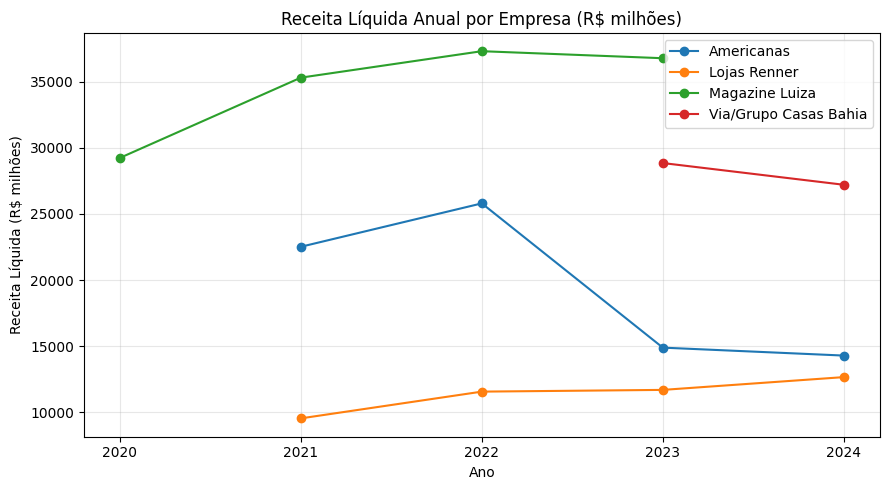

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for empresa, grupo in df_prep.dropna(subset=["receita_liquida_r_milhoes"]).groupby("empresa"):
    grupo = grupo.sort_values("ano")
    ax.plot(grupo["ano"], grupo["receita_liquida_r_milhoes"], marker="o", label=empresa)
ax.set_title("Receita Líquida Anual por Empresa (R$ milhões)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("Ano")
ax.set_ylabel("Receita Líquida (R$ milhões)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../dataset/fig_receita_liquida.png", dpi=150)
plt.show()

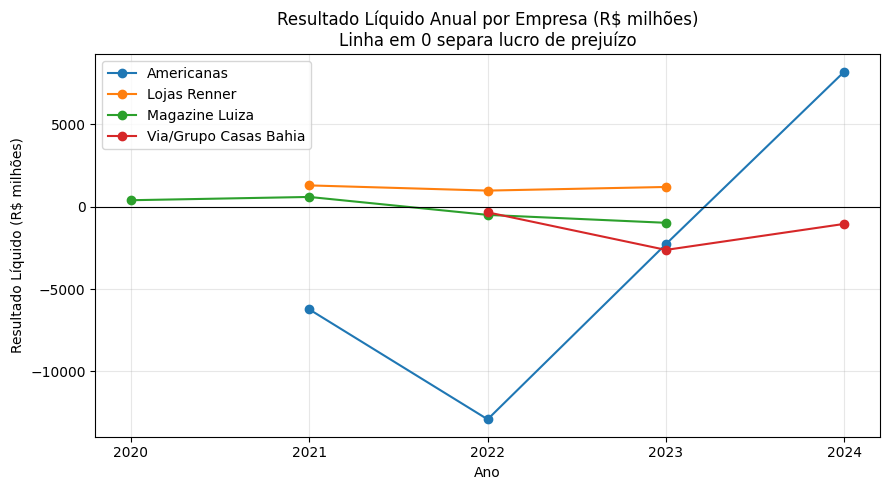

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for empresa, grupo in df_prep.dropna(subset=["resultado_liquido_r_milhoes"]).groupby("empresa"):
    grupo = grupo.sort_values("ano")
    ax.plot(grupo["ano"], grupo["resultado_liquido_r_milhoes"], marker="o", label=empresa)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Resultado Líquido Anual por Empresa (R$ milhões)\nLinha em 0 separa lucro de prejuízo")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("Ano")
ax.set_ylabel("Resultado Líquido (R$ milhões)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../dataset/fig_resultado_liquido.png", dpi=150)
plt.show()

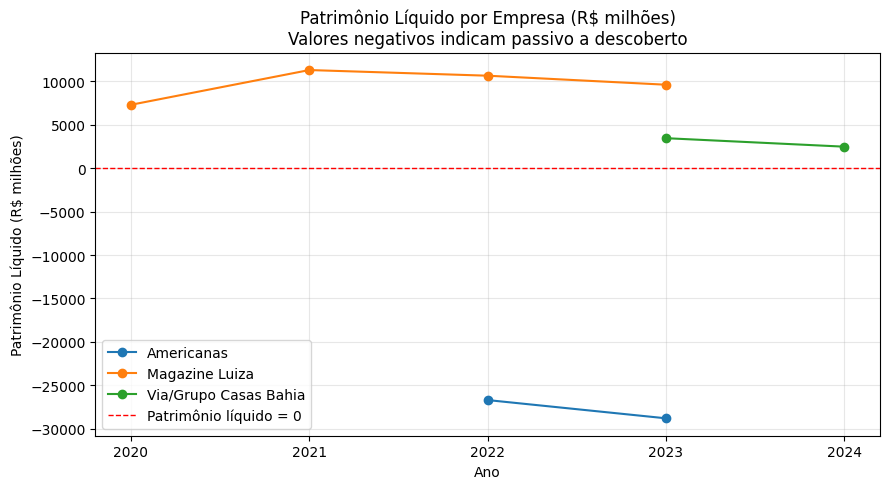

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
pl_df = df_prep.dropna(subset=["patrimonio_liquido_r_milhoes"]).sort_values(["empresa", "ano"])
for empresa, grupo in pl_df.groupby("empresa"):
    ax.plot(grupo["ano"], grupo["patrimonio_liquido_r_milhoes"], marker="o", label=empresa)
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="Patrimônio líquido = 0")
ax.set_title("Patrimônio Líquido por Empresa (R$ milhões)\nValores negativos indicam passivo a descoberto")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("Ano")
ax.set_ylabel("Patrimônio Líquido (R$ milhões)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../dataset/fig_patrimonio_liquido.png", dpi=150)
plt.show()

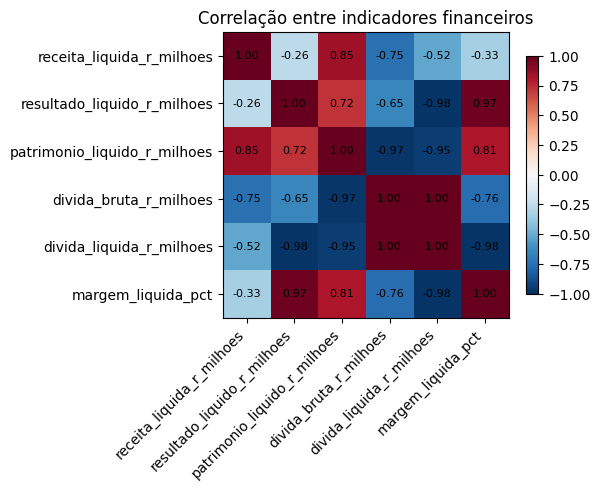

In [10]:
corr = df_prep[num_cols + ["margem_liquida_pct"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlação entre indicadores financeiros")
fig.tight_layout()
fig.savefig("../dataset/fig_correlacao.png", dpi=150)
plt.show()

                          cenario  resultado_liquido_r_milhoes
0  Divulgado originalmente (2021)                          544
1  Republicado apos fraude (2021)                        -6237


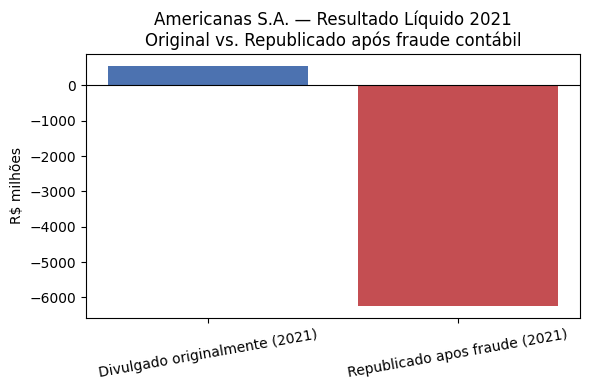

In [11]:
# Comparacao entre o resultado ORIGINALMENTE divulgado em 2021 (lucro de
# R$544 milhoes) e o valor REPUBLICADO apos a descoberta da fraude contabil
# (prejuizo de R$6.237 bilhoes) - ilustra por que sinais textuais em releases
# e notas explicativas (o que a solucao de N2 via LLM buscara explorar) podem
# ser tao importantes quanto os numeros reportados.
comparacao_restatement = pd.DataFrame({
    "cenario": ["Divulgado originalmente (2021)", "Republicado apos fraude (2021)"],
    "resultado_liquido_r_milhoes": [544, -6237],
})
print(comparacao_restatement)

fig, ax = plt.subplots(figsize=(6, 4))
cores = ["#4C72B0", "#C44E52"]
ax.bar(comparacao_restatement["cenario"], comparacao_restatement["resultado_liquido_r_milhoes"], color=cores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Americanas S.A. — Resultado Líquido 2021\nOriginal vs. Republicado após fraude contábil")
ax.set_ylabel("R$ milhões")
plt.xticks(rotation=10)
fig.tight_layout()
fig.savefig("../dataset/fig_americanas_restatement.png", dpi=150)
plt.show()

In [12]:
df_prep.to_csv("../dataset/demonstrativos_financeiros_varejo_br_prep.csv", index=False)
print("Dataset preparado exportado para dataset/demonstrativos_financeiros_varejo_br_prep.csv")

Dataset preparado exportado para dataset/demonstrativos_financeiros_varejo_br_prep.csv


In [13]:
print("""
Principais achados da analise exploratoria:

1. Das 4 empresas, Americanas e Via/Grupo Casas Bahia concentram os anos com
   patrimonio liquido negativo e/ou prejuizo continuado, enquanto Lojas Renner
   e a unica com resultado liquido positivo em todos os anos disponiveis.
2. O caso Americanas evidencia como um numero unico (lucro de 2021) pode
   mascarar risco real: apos a descoberta da fraude contabil, o mesmo ano
   passou de lucro de R$544 milhoes para prejuizo de R$6,2 bilhoes.
3. Ha lacunas relevantes de dados (ver README do dataset) que exigirao, para a
   N2, tanto a busca por fontes primarias completas (DFP/ITR da CVM) quanto o
   uso do LLM para extrair automaticamente indicadores a partir do texto
   integral dos relatorios de RI, reduzindo a dependencia de coleta manual.
4. Os indicadores de alavancagem e patrimonio liquido negativo servem como
   ponto de partida para a heuristica de "sinal de alerta de risco" que o
   assistente baseado em LLM (N2) devera aprimorar e explicar em linguagem
   natural a partir da leitura dos documentos de RI.
""")


Principais achados da analise exploratoria:

1. Das 4 empresas, Americanas e Via/Grupo Casas Bahia concentram os anos com
   patrimonio liquido negativo e/ou prejuizo continuado, enquanto Lojas Renner
   e a unica com resultado liquido positivo em todos os anos disponiveis.
2. O caso Americanas evidencia como um numero unico (lucro de 2021) pode
   mascarar risco real: apos a descoberta da fraude contabil, o mesmo ano
   passou de lucro de R$544 milhoes para prejuizo de R$6,2 bilhoes.
3. Ha lacunas relevantes de dados (ver README do dataset) que exigirao, para a
   N2, tanto a busca por fontes primarias completas (DFP/ITR da CVM) quanto o
   uso do LLM para extrair automaticamente indicadores a partir do texto
   integral dos relatorios de RI, reduzindo a dependencia de coleta manual.
4. Os indicadores de alavancagem e patrimonio liquido negativo servem como
   ponto de partida para a heuristica de "sinal de alerta de risco" que o
   assistente baseado em LLM (N2) devera aprimorar e e